In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train = X_train[..., None]
X_test = X_test[..., None]

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print(X_train.shape)
print(y_train.shape)

(60000, 28, 28, 1)
(60000, 10)


In [5]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
)

model = Sequential([
    Input(shape=(28, 28, 1)),

    Conv2D(32, (3,3), activation="relu"),
    MaxPooling2D(),

    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(10, activation="softmax")
])

In [7]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [8]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 49s 25ms/step - accuracy: 0.7510 - loss: 0.6873 - val_accuracy: 0.8672 - val_loss: 0.3594
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 76s 22ms/step - accuracy: 0.8727 - loss: 0.3480 - val_accuracy: 0.8823 - val_loss: 0.3144
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.8908 - loss: 0.3005 - val_accuracy: 0.8921 - val_loss: 0.2902
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9004 - loss: 0.2641 - val_accuracy: 0.8953 - val_loss: 0.2926
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9121 - loss: 0.2368 - val_accuracy: 0.9036 - val_loss: 0.2637
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9184 - loss: 0.2160 - val_accuracy: 0.9063 - val_loss: 0.2525
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9268 - loss: 0.1987 - val_accuracy: 0.9096 - val_loss: 0.2471
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9313 -

In [9]:
loss, accuracy = model.evaluate(X_test, y_test)

print(f"Test Accuracy: {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9037 - loss: 0.2816
Test Accuracy: 0.9056


In [10]:
import os

os.makedirs("../app/models", exist_ok=True)

model.save("../app/models/product_classifier.h5")

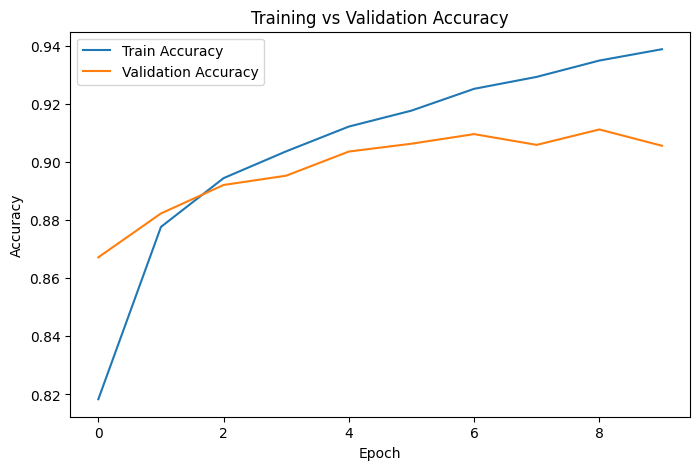

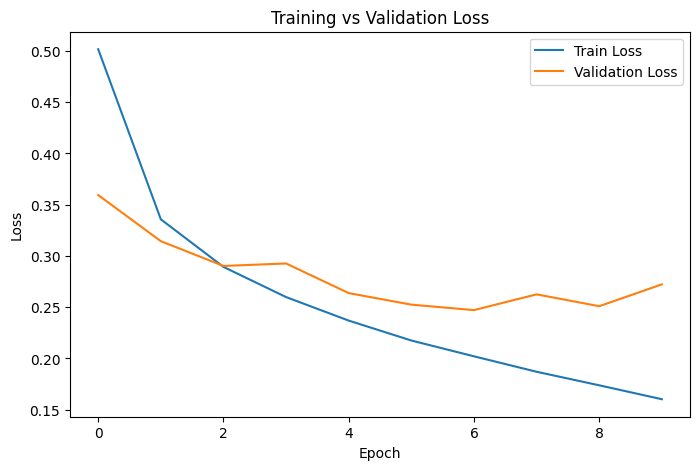

In [11]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

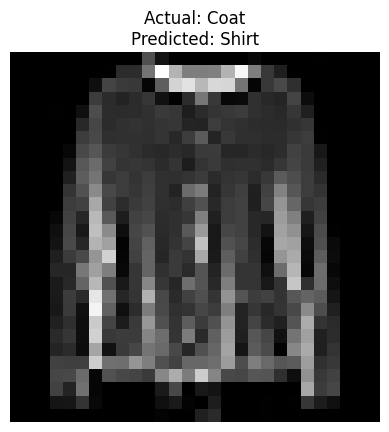

In [12]:
import numpy as np
import matplotlib.pyplot as plt

class_names = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot",
]

index = 25  # Change this number to test different images

image = X_test[index]

prediction = model.predict(np.expand_dims(image, axis=0), verbose=0)

predicted_class = class_names[np.argmax(prediction)]
actual_class = class_names[np.argmax(y_test[index])]

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Actual: {actual_class}\nPredicted: {predicted_class}")
plt.axis("off")
plt.show()

In [15]:
import os

os.makedirs("../app/models", exist_ok=True)
model.save("../app/models/product_classifier.h5")

In [14]:
import os
print(os.getcwd())

d:\smart_retail_ai\notebooks


In [16]:
import os

path = "../app/models/product_classifier.h5"   # change to "app/models/..." if needed

print("Exists:", os.path.exists(path))
print("Size:", os.path.getsize(path), "bytes")

Exists: True
Size: 2741312 bytes


In [17]:
with open(r"D:\smart_retail_ai\backend\app\models\product_classifier.h5", "rb") as f:
    print(f.read(16))

b''


In [18]:
model.save("../app/models/product_classifier.keras")


In [19]:
from tensorflow.keras.models import load_model

m = load_model("../app/models/product_classifier.keras")
print("Loaded successfully")

Loaded successfully


c:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [20]:
import tensorflow as tf
import keras

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)


TensorFlow: 2.18.0
Keras: 3.7.0


In [21]:
import os
print(os.getcwd())

d:\smart_retail_ai\notebooks


In [22]:
model.save("../app/models/product_classifier.keras")

In [23]:
model.save("app/models/product_classifier.keras")

FileNotFoundError: [Errno 2] No such file or directory: 'app/models/product_classifier.keras'

In [24]:
import os

print("Current directory:", os.getcwd())

for root, dirs, files in os.walk(os.getcwd()):
    for file in files:
        if file.endswith(".keras"):
            print(os.path.join(root, file))

Current directory: d:\smart_retail_ai\notebooks


In [25]:
import os

os.makedirs(r"D:\smart_retail_ai\backend\app\models", exist_ok=True)

model.save(r"D:\smart_retail_ai\backend\app\models\product_classifier.keras")

In [26]:
import os

path = r"D:\smart_retail_ai\backend\app\models\product_classifier.keras"
print(os.path.exists(path))
print(os.path.getsize(path))

True
2739478


In [2]:
!pip install kagglehub


   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ------------------------------------

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paramaggarwal/fashion-product-images-dataset")

print("Path to dataset files:", path)

  0%|          | 45.0M/23.1G [00:41<6:00:47, 1.14MB/s]


KeyboardInterrupt: 

In [4]:
import os

os.environ["KAGGLEHUB_CACHE"] = r"D:\KaggleHub"

import kagglehub

path = kagglehub.dataset_download("diyer22/retail-product-checkout-dataset")

print(path)

  0%|          | 15.0M/25.3G [04:35<132:25:52, 57.0kB/s]


KeyboardInterrupt: 

In [5]:
pip install icrawler


   -------------------- ------------------- 1/2 [icrawler]
   -------------------- ------------------- 1/2 [icrawler]
   -------------------- ------------------- 1/2 [icrawler]
   -------------------- ------------------- 1/2 [icrawler]
   -------------------- ------------------- 1/2 [icrawler]
   ---------------------------------------- 2/2 [icrawler]

Note: you may need to restart the kernel to use updated packages.


In [6]:
from icrawler.builtin import BingImageCrawler
import os
import time

# Change this if you want the dataset elsewhere
DATASET_DIR = "dataset"

# 10 retail product classes
classes = {
    "biscuits": "biscuits packet",
    "chips": "chips packet",
    "chocolate": "chocolate bar",
    "milk": "milk carton",
    "juice": "juice box",
    "soft_drink": "soft drink bottle",
    "shampoo": "shampoo bottle",
    "soap": "soap bar",
    "toothpaste": "toothpaste tube",
    "instant_noodles": "instant noodles packet"
}

IMAGES_PER_CLASS = 40

for folder, keyword in classes.items():

    save_dir = os.path.join(DATASET_DIR, folder)
    os.makedirs(save_dir, exist_ok=True)

    print(f"\nDownloading {folder}...")

    crawler = BingImageCrawler(
        downloader_threads=4,
        storage={"root_dir": save_dir}
    )

    crawler.crawl(
        keyword=keyword,
        max_num=IMAGES_PER_CLASS
    )

    time.sleep(2)

print("\nDataset download completed!")

2026-07-29 10:32:43,487 - INFO - icrawler.crawler - start crawling...
2026-07-29 10:32:43,487 - INFO - icrawler.crawler - starting 1 feeder threads...
2026-07-29 10:32:43,490 - INFO - feeder - thread feeder-001 exit
2026-07-29 10:32:43,495 - INFO - icrawler.crawler - starting 1 parser threads...
2026-07-29 10:32:43,495 - INFO - icrawler.crawler - starting 4 downloader threads...


2026-07-29 10:32:44,684 - INFO - parser - parsing result page https://www.bing.com/images/async?q=biscuits packet&first=0
2026-07-29 10:32:45,097 - INFO - parser - parsing result page https://www.bing.com/images/async?q=biscuits packet&first=20
2026-07-29 10:32:47,112 - INFO - parser - no more page urls for thread parser-001 to parse
2026-07-29 10:32:47,112 - INFO - parser - thread parser-001 exit
2026-07-29 10:32:47,363 - INFO - downloader - image #1	https://anationofmoms.com/wp-content/uploads/2021/03/solar-system-battery.jpg
2026-07-29 10:32:48,508 - INFO - downloader - no more download task for thread downloader-004
2026-07-29 10:32:48,511 - INFO - downloader - no more download task for thread downloader-002
2026-07-29 10:32:48,511 - INFO - downloader - no more download task for thread downloader-003
2026-07-29 10:32:48,511 - INFO - downloader - thread downloader-004 exit
2026-07-29 10:32:48,515 - INFO - downloader - thread downloader-002 exit
2026-07-29 10:32:48,524 - INFO - downl

2026-07-29 10:32:55,699 - INFO - parser - parsing result page https://www.bing.com/images/async?q=chips packet&first=0
2026-07-29 10:32:56,363 - INFO - downloader - image #1	https://people.com/thmb/w81wblV_TPI3xr-I2Zrq-5RsLIk=/4000x0/filters:no_upscale():max_bytes(150000):strip_icc():focal(999x0:1001x2)/haim-3-11128758bee042759a586ec9a255854e.jpg
2026-07-29 10:32:59,459 - INFO - downloader - image #2	https://cdn.wegow.com/media/artists/haim/haim-1515432746.34.2560x1440.jpg
2026-07-29 10:32:59,909 - INFO - downloader - image #3	https://static.spin.com/files/2017/07/GettyImages-809455128-1499367874-compressed.jpg
2026-07-29 10:33:00,215 - INFO - downloader - image #4	https://www.billboard.com/wp-content/uploads/2025/06/Haim-Relationships-Artwork-2025-billboard-1240.jpg
2026-07-29 10:33:00,977 - INFO - downloader - image #5	https://www.the-sun.com/wp-content/uploads/sites/6/2018/02/nintchdbpict000381294694.jpg
2026-07-29 10:33:01,048 - INFO - downloader - image #6	https://pyxis.nymag.com/

2026-07-29 10:33:19,565 - INFO - parser - parsing result page https://www.bing.com/images/async?q=chocolate bar&first=0
2026-07-29 10:33:20,083 - INFO - parser - parsing result page https://www.bing.com/images/async?q=chocolate bar&first=20
2026-07-29 10:33:20,968 - INFO - downloader - image #1	https://i.ytimg.com/vi/7R_0kopuLOs/maxresdefault.jpg
2026-07-29 10:33:22,102 - INFO - parser - no more page urls for thread parser-001 to parse
2026-07-29 10:33:22,104 - INFO - parser - thread parser-001 exit
2026-07-29 10:33:23,597 - INFO - downloader - no more download task for thread downloader-003
2026-07-29 10:33:23,601 - INFO - downloader - no more download task for thread downloader-002
2026-07-29 10:33:23,601 - INFO - downloader - no more download task for thread downloader-004
2026-07-29 10:33:23,601 - INFO - downloader - thread downloader-003 exit
2026-07-29 10:33:23,607 - INFO - downloader - thread downloader-002 exit
2026-07-29 10:33:23,610 - INFO - downloader - thread downloader-004

2026-07-29 10:33:29,543 - INFO - parser - parsing result page https://www.bing.com/images/async?q=milk carton&first=0
2026-07-29 10:33:30,107 - INFO - parser - parsing result page https://www.bing.com/images/async?q=milk carton&first=20
2026-07-29 10:33:30,509 - INFO - downloader - image #1	https://as2.ftcdn.net/v2/jpg/02/12/20/39/1000_F_212203952_pNOXIjZcuR8ETfCZO7QFl7FQZTiHGPLw.jpg
2026-07-29 10:33:30,515 - INFO - downloader - image #2	https://media-cdn.tripadvisor.com/media/photo-m/1280/17/15/6d/d6/paris.jpg
2026-07-29 10:33:30,963 - INFO - downloader - image #3	https://static.vecteezy.com/system/resources/previews/027/002/084/large_2x/aerial-view-of-the-eiffel-tower-at-sunset-paris-france-aerial-panoramic-view-of-paris-with-eiffel-tower-at-sunset-france-ai-generated-free-photo.jpg
2026-07-29 10:33:31,122 - INFO - downloader - image #4	https://cdn.wallpapersafari.com/15/5/RQF2z0.jpg
2026-07-29 10:33:32,641 - INFO - downloader - image #5	https://a.cdn-hotels.com/gdcs/production169/d8

...

2026-07-29 10:34:16,327 - INFO - parser - parsing result page https://www.bing.com/images/async?q=shampoo bottle&first=0
2026-07-29 10:34:16,590 - INFO - downloader - image #1	https://i0.wp.com/s3.ap-south-1.amazonaws.com/img.paisawapas/images/2023/01/23174949/Top-15-Shampoo-Brands-in-India.jpg
2026-07-29 10:34:16,794 - INFO - downloader - image #2	https://www.realsimple.com/thmb/KvuCUeuPcuG5fCxxQnMEXOZ-Ins=/1500x0/filters:no_upscale():max_bytes(150000):strip_icc()/Best-Shampoos-for-Dry-Hair-of-2023-tout-f46eb10c0a634a05b49bcf6256320ef3.jpg
2026-07-29 10:34:17,290 - INFO - downloader - image #3	https://hips.hearstapps.com/hmg-prod.s3.amazonaws.com/images/hbz-shampoo-index-1585859074.jpg
2026-07-29 10:34:17,573 - INFO - downloader - image #4	https://media-cldnry.s-nbcnews.com/image/upload/t_nbcnews-fp-1200-630,f_auto,q_auto:best/newscms/2022_39/3572908/220927-best-shampoos-vl-2x1.jpg
2026-07-29 10:34:17,613 - INFO - downloader - image #5	https://m.media-amazon.com/images/I/91LgTT5weYL.j

2026-07-29 10:34:33,089 - INFO - parser - parsing result page https://www.bing.com/images/async?q=soap bar&first=0
2026-07-29 10:34:33,843 - ERROR - downloader - Response status code 400, file https://images.sidearmdev.com/fit?url=https:%2f%2fdbukjj6eu5tsf.cloudfront.net%2fsidearm.sites%2fchgo.sidearmsports.com%2fimages%2f2024%2f3%2f9%2fBB-Grinnell-Team__14_.jpg
2026-07-29 10:34:34,072 - ERROR - downloader - Response status code 400, file https://images.sidearmdev.com/fit?url=https:%2f%2fdbukjj6eu5tsf.cloudfront.net%2fsidearm.sites%2fchgo.sidearmsports.com%2fimages%2f2026%2f2%2f21%2fWLACR_20260221_UChi-UWRF_AlexAkhundov_Quick_001.jpg
2026-07-29 10:34:34,105 - ERROR - downloader - Response status code 400, file https://images.sidearmdev.com/fit?url=https:%2f%2fdbukjj6eu5tsf.cloudfront.net%2fsidearm.sites%2fchgo.sidearmsports.com%2fimages%2f2025%2f9%2f9%2fVB-Team-UWEC-25i.jpg
2026-07-29 10:34:34,357 - ERROR - downloader - Response status code 400, file https://images.sidearmdev.com/fit?u

2026-07-29 10:35:01,202 - INFO - parser - parsing result page https://www.bing.com/images/async?q=toothpaste tube&first=0
2026-07-29 10:35:02,008 - INFO - downloader - image #1	https://wallpapercave.com/wp/wp5477041.jpg
2026-07-29 10:35:02,189 - INFO - downloader - image #2	https://wallpapercave.com/wp/wp7414614.jpg
2026-07-29 10:35:02,347 - INFO - downloader - image #3	https://wallpapercave.com/wp/wp4194146.jpg
2026-07-29 10:35:03,501 - INFO - downloader - image #4	https://wallpapercave.com/wp/wp2207596.jpg
2026-07-29 10:35:04,573 - INFO - downloader - image #5	https://wallpapercave.com/wp/wp5264665.jpg
2026-07-29 10:35:05,558 - INFO - downloader - image #6	https://i.etsystatic.com/49587724/r/il/58083a/6094275288/il_fullxfull.6094275288_w781.jpg
2026-07-29 10:35:06,023 - INFO - downloader - image #7	https://wallpapercave.com/wp/wp6919734.jpg
2026-07-29 10:35:06,240 - INFO - downloader - image #8	https://wallpapers.com/images/hd/pretty-pink-flowers-aesthetic-k8k25mj93ahh4gdr.jpg
2026-0

2026-07-29 10:35:26,473 - INFO - parser - parsing result page https://www.bing.com/images/async?q=instant noodles packet&first=0
2026-07-29 10:35:27,498 - INFO - downloader - image #1	https://i.ytimg.com/vi/BS91VsxQ9eg/maxresdefault.jpg
2026-07-29 10:35:27,739 - INFO - downloader - image #2	https://image.itmedia.co.jp/bt/articles/1704/11/rk_170410_autodesk01.jpg
2026-07-29 10:35:27,817 - INFO - downloader - image #3	https://i.ytimg.com/vi/AX1SmVCuxhI/maxresdefault.jpg
2026-07-29 10:35:27,839 - INFO - downloader - image #4	https://i.ytimg.com/vi/sj_jz_nOs1s/maxresdefault.jpg
2026-07-29 10:35:27,862 - INFO - downloader - image #5	https://i.ytimg.com/vi/lSdzhZjSgDc/maxresdefault.jpg
2026-07-29 10:35:28,088 - INFO - downloader - image #6	https://i.ytimg.com/vi/0lLXcdJV7cw/hqdefault.jpg
2026-07-29 10:35:28,407 - INFO - downloader - image #7	https://i.ytimg.com/vi/ETvqv763wHc/maxresdefault.jpg
2026-07-29 10:35:29,091 - INFO - downloader - image #8	https://news.mynavi.jp/techplus/kikaku/20181


Dataset download completed!
